# Xây dựng Kiến trúc MetaBlock Fusion (Gated Attention)

- **Bản chất**: Dữ liệu Tuổi/Vị trí không cộng dồn nữa, mà kích hoạt một lớp Màng lọc `Sigmoid Gate`, làm tăng/giảm sự chi tiết của Dữ liệu Ảnh.
- **Interpretability**: Lấy được số liệu Cổng Gate Attention để biết được Dữ liệu Bảng đóng góp bao nhiêu vào Bức ảnh.

In [1]:
import sys; sys.path.append('../..')
import torch
import torch.nn as nn
import torch.nn.functional as F
from _shared_fusion_env import get_dataloaders, get_device
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import timm
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Thu viện Grad-CAM XAI
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = get_device()
train_loader, test_loader, weights, tab_dim = get_dataloaders(batch_size=32, use_advanced_aug=True, data_folder='data_no_smote')
weights = weights.to(device)
print(f"Device: {device} | Tabular Dim: {tab_dim}")



Device: mps | Tabular Dim: 58


/Users/hhh/workspace/School/PBL7/src/Model_training/MetaBlock_Fusion/Advanced_Augmentation/../../_shared_fusion_env.py:73: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=2, min_height=8, min_width=8, p=0.5),
/Users/hhh/workspace/School/PBL7/src/Model_training/MetaBlock_Fusion/Advanced_Augmentation/../../_shared_fusion_env.py:73: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=2, min_height=8, min_width=8, p=0.5),


In [2]:
class MetaBlockFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=6):
        super().__init__()
        # Xương sống ConvNeXt Tiny
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        self.img_net = convnext.features # Sequential block (B, 768, 7, 7)
        
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512)
        )
        self.img_proj = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        
        self.attention_gate = nn.Sequential(
            nn.Linear(512 + 512, 512),
            nn.Sigmoid()
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img, tab, return_gate=False):
        f_img_raw = self.img_net(img)
        # Spatial Pooling Global cho CNN
        f_img_raw = torch.flatten(nn.AdaptiveAvgPool2d((1, 1))(f_img_raw), 1)
        
        f_img = self.img_proj(f_img_raw)
        f_tab = self.tab_proj(tab)
        
        combined = torch.cat([f_img, f_tab], dim=1)
        gate = self.attention_gate(combined)
        fused = gate * f_img + (1.0 - gate) * f_tab
        
        out = self.classifier(fused)
        if return_gate:
            return out, gate
        return out


In [ ]:
model = MetaBlockFusionModel(tab_dim).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

E1, E2 = 10, 140
# Giai đoạn 1: Luyện tập Meta Block
for param in model.img_net.parameters(): param.requires_grad = False
opt1 = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, momentum=0.9, weight_decay=1e-3)

print("=== Phase 1: Attention Module Training (SGD) ===")
for ep in range(E1):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt1.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls) 
        loss.backward()
        opt1.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1}/{E1} | Train Loss: {running_loss/len(train_loader):.4f}")

# Giai đoạn 2: Bấm nút Unfreeze và ReduceLROnPlateau
for param in model.parameters(): param.requires_grad = True
opt2 = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-3)
scheduler2 = ReduceLROnPlateau(opt2, mode='max', patience=10, factor=0.1, min_lr=1e-6)

print("\n=== Phase 2: End-to-end Fine-tuning w/ ReduceLROnPlateau ===")
best_bcc = 0.0
patience = 15 # Chờ SGD khá lâu
stagnant = 0
import os
os.makedirs('../../../saved_models', exist_ok=True)
best_model_path = '../../../saved_models/nosmote_convnext_best.pth'

for ep in range(E2):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt2.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls)
        loss.backward()
        opt2.step()
        running_loss += loss.item()
    
    # --- EVALUATION LOOP ---
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, tabs, lbls in test_loader:
            out = model(imgs.to(device), tabs.to(device))
            _, y_hat = torch.max(out, 1)
            preds.extend(y_hat.cpu().numpy())
            trues.extend(lbls.numpy())
            
    val_bcc = balanced_accuracy_score(trues, preds)
    val_f1 = f1_score(trues, preds, average='macro')
    current_lr = opt2.param_groups[0]['lr']
    print(f"Epoch {ep+E1+1}/{E1+E2} | Train Loss: {running_loss/len(train_loader):.4f} | Val BCC: {val_bcc*100:.2f}% | LR: {current_lr:.2e}")
    
    scheduler2.step(val_bcc) # Feed metric here!!
    
    if val_bcc > best_bcc:
        best_bcc = val_bcc
        stagnant = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"   --> [+] Đỉnh cao mới BCC: {val_bcc*100:.2f}%! Đã lưu Checkpoint.")
    else:
        stagnant += 1
        if stagnant >= patience:
            print(f"   --> [-] Early Stopping kích hoạt. Khôi phục tự động mô hình tốt nhất...")
            model.load_state_dict(torch.load(best_model_path))
            break



=== Phase 1: Attention Module Training (SGD) ===


/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/57 [00:06<?, ?it/s]

Epoch 1/10 | Train Loss: 1.9867


  0%|          | 0/57 [00:00<?, ?it/s]

...

Epoch 34/70 | Train Loss: 0.4718 | Val BCC: 69.14% | LR: 1.00e-05


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 35/70 | Train Loss: 0.4528 | Val BCC: 69.23% | LR: 1.00e-05


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 36/70 | Train Loss: 0.4627 | Val BCC: 68.91% | LR: 1.00e-05
   --> [-] Early Stopping kích hoạt. Khôi phục tự động mô hình tốt nhất...


## Khả năng Giải thích XAI: Tham số Attention Gate 
Xuất thông số cường độ hoạt động của Sigmoid Gate.

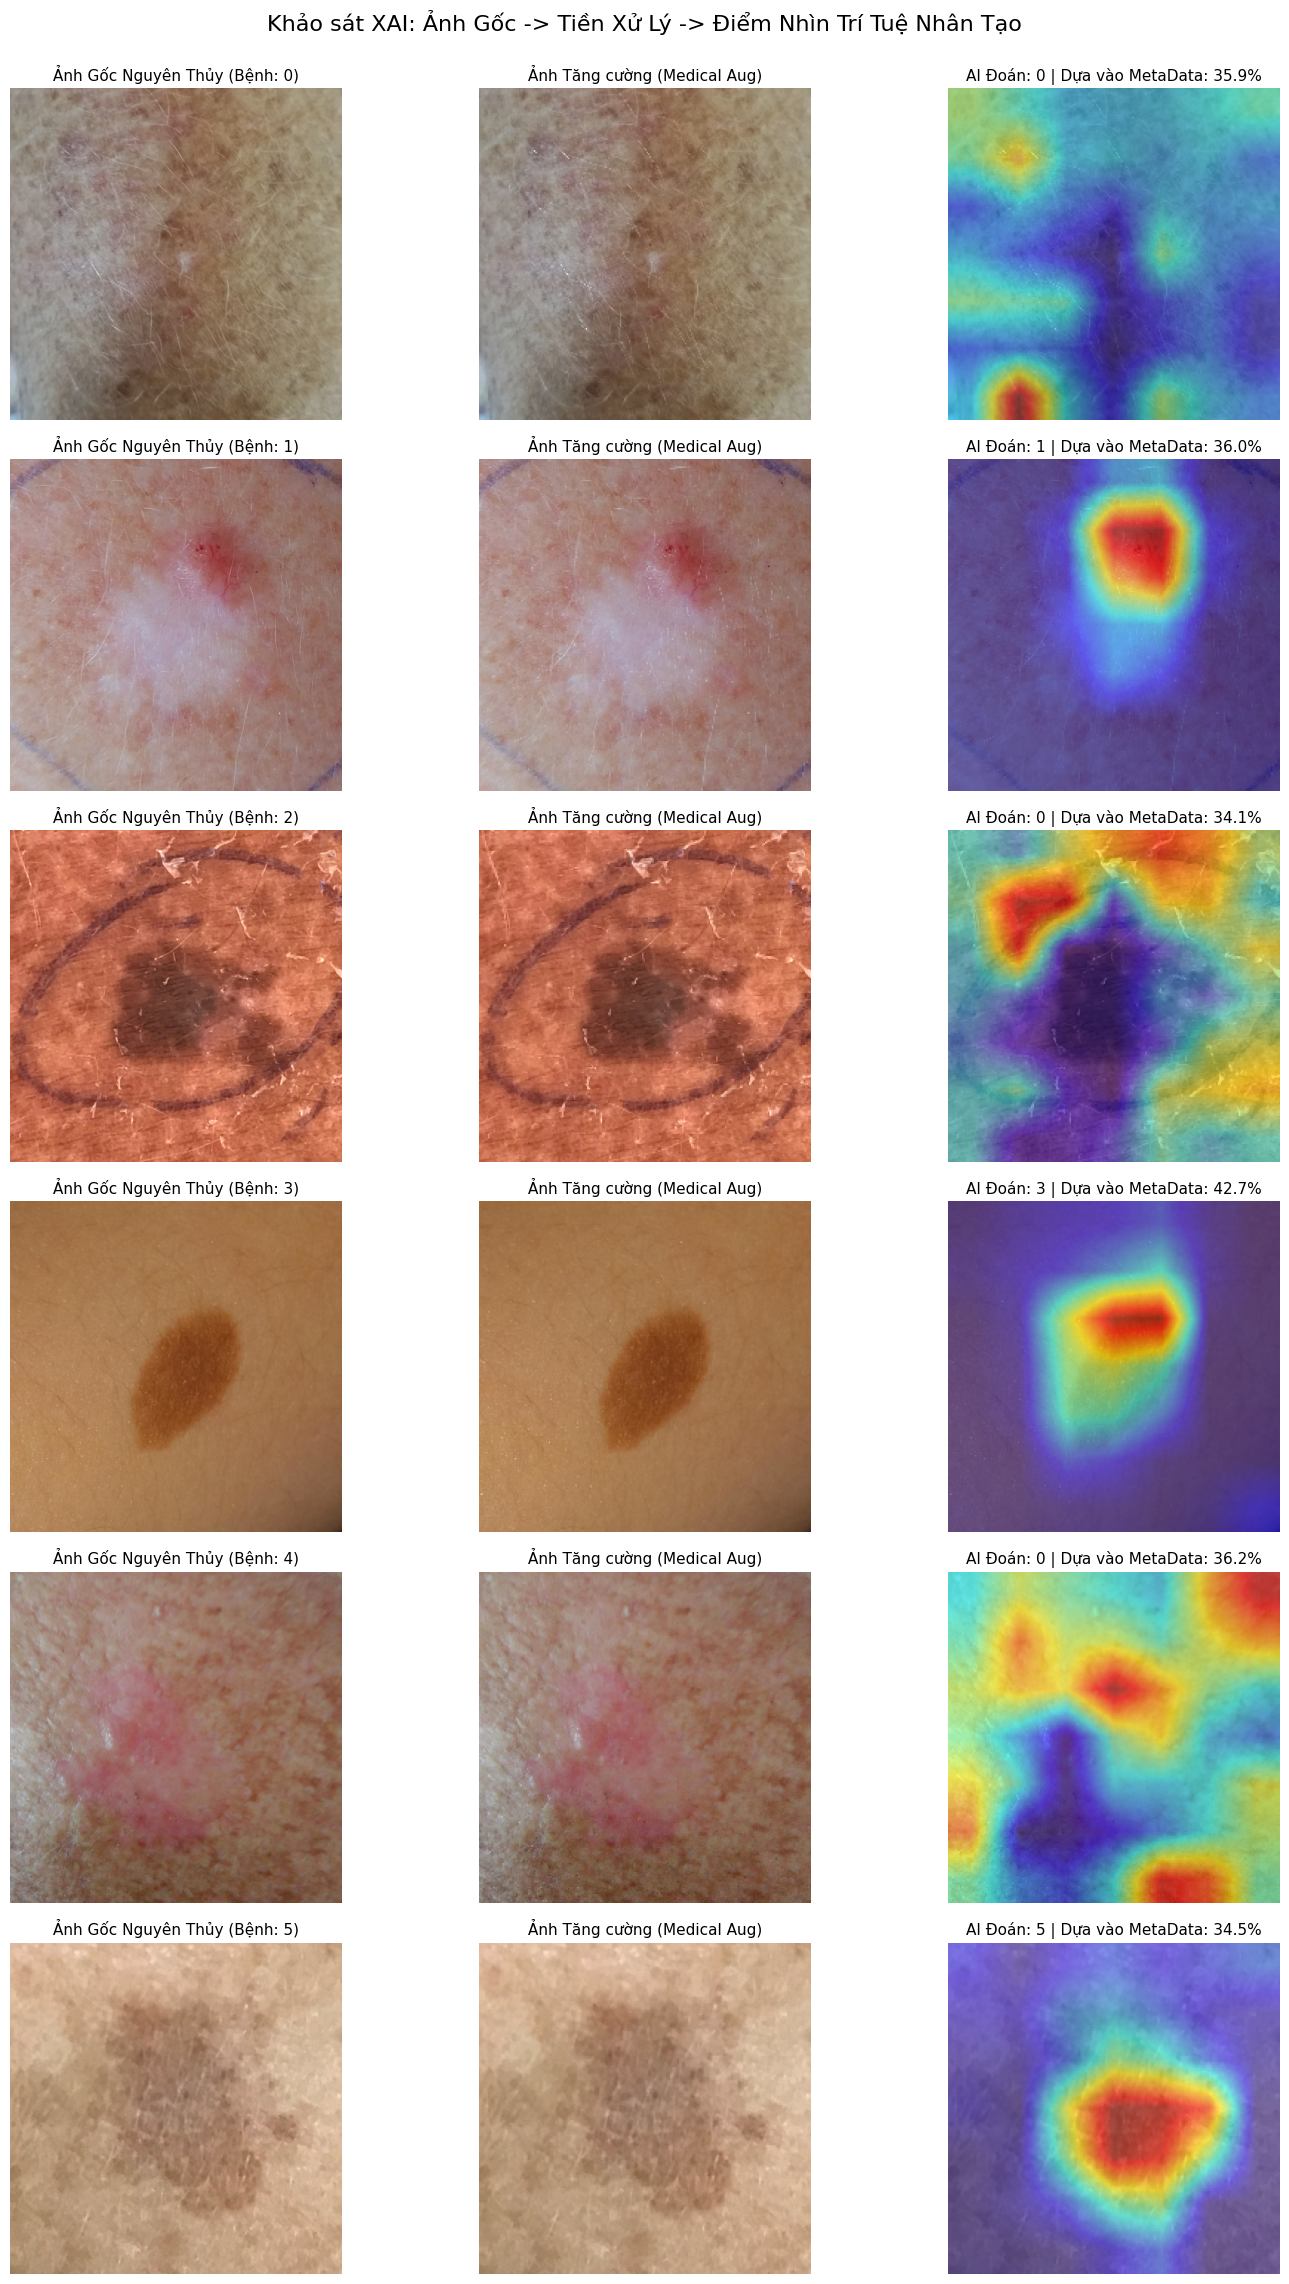

In [4]:
class ModelCAMWrapper(nn.Module):
    def __init__(self, model, fixed_tab):
        super().__init__()
        self.model = model
        self.fixed_tab = fixed_tab
    def forward(self, img):
        return self.model(img, self.fixed_tab, return_gate=False)

model.eval()

import cv2
# Tìm đủ 6 ảnh mang 6 nhãn bệnh khác nhau để Demo (Từ 0 đến 5)
found_classes = set()
selected_raw_imgs = []
selected_aug_imgs = []
selected_tabs = []
selected_lbls = []

test_ds = test_loader.dataset
for idx in range(len(test_ds)):
    img_tensor, tab_tensor, lbl = test_ds[idx]
    c = lbl.item()
    if c not in found_classes:
        found_classes.add(c)
        # Fetch RAW image directly
        img_id = str(test_ds.df_map.iloc[idx]['img_id'])
        if not img_id.endswith('.png'): img_id += '.png'
        img_path = test_ds.img_paths_dict.get(img_id)
        raw_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        
        selected_raw_imgs.append(raw_img)
        selected_aug_imgs.append(img_tensor)
        selected_tabs.append(tab_tensor)
        selected_lbls.append(c)
    if len(found_classes) == 6:
        break

# Sắp xếp lại danh sách từ Nhãn 0 đến Nhãn 5 cho ngăn nắp
sorted_indices = np.argsort(selected_lbls)
selected_raw_imgs = [selected_raw_imgs[idx] for idx in sorted_indices]
selected_aug_imgs = [selected_aug_imgs[idx] for idx in sorted_indices]
selected_tabs = [selected_tabs[idx] for idx in sorted_indices]
selected_lbls = [selected_lbls[idx] for idx in sorted_indices]

target_layer = [model.img_net[-1]]

fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for i in range(6):
    img_tensor = selected_aug_imgs[i].unsqueeze(0).to(device)
    tab_tensor = selected_tabs[i].unsqueeze(0).to(device)
    wrap_model = ModelCAMWrapper(model, tab_tensor)
    
    # Rút Bản đồ nhiệt
    cam = GradCAM(model=wrap_model, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_img = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    rgb_img = np.clip(std * rgb_img + mean, 0, 1)
    
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # Rút Trọng số Cổng Gate
    out, gate_val = model(img_tensor, tab_tensor, return_gate=True)
    mean_gate = gate_val.mean().item() 
    
    pred_val = torch.argmax(out).item()
    true_val = selected_lbls[i]
    raw_img = selected_raw_imgs[i]
    
    # Ô 1: Ảnh Gốc Thuần tuý
    axes[i, 0].imshow(raw_img)
    axes[i, 0].set_title(f"Ảnh Gốc Nguyên Thủy (Bệnh: {true_val})", fontsize=11)
    axes[i, 0].axis('off')
    
    # Ô 2: Ảnh Augmented (Medical Aug)
    axes[i, 1].imshow(rgb_img)
    axes[i, 1].set_title(f"Ảnh Tăng cường (Medical Aug)", fontsize=11)
    axes[i, 1].axis('off')
    
    # Ô 3: Bản Đồ Nhiệt
    axes[i, 2].imshow(visualization)
    axes[i, 2].set_title(f"AI Đoán: {pred_val} | Dựa vào MetaData: {(1.0 - mean_gate)*100:.1f}%", fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle("Khảo sát XAI: Ảnh Gốc -> Tiền Xử Lý -> Điểm Nhìn Trí Tuệ Nhân Tạo", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


  0%|          | 0/15 [00:00<?, ?it/s]


MetaBlock Fusion F1-Macro Score: 0.6816


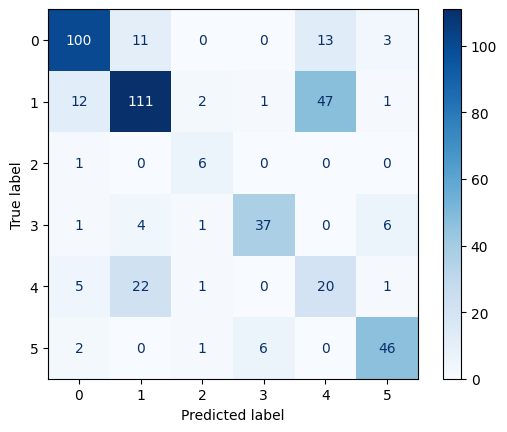

In [5]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in tqdm(test_loader):
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        preds.extend(y_hat.cpu().numpy())
        trues.extend(lbls.numpy())

f1 = f1_score(trues, preds, average='macro')
print(f"\nMetaBlock Fusion F1-Macro Score: {f1:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix(trues, preds))
disp.plot(cmap='Blues')
plt.show()

## Lưu Mô hình (Model Checkpoint)
Bảo toàn Trọng số học được (Weights) để phục vụ cho Test độc lập hoặc Triển khai Web App/Mobile sau này mà không cần Train lại.

In [6]:
import os
os.makedirs('../../../saved_models', exist_ok=True)
save_path = '../../../saved_models/nosmote_convnext_best.pth'
torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu trọng số mô hình tại: {save_path}")


✅ Đã lưu trọng số mô hình tại: ../../../saved_models/nosmote_convnext_best.pth


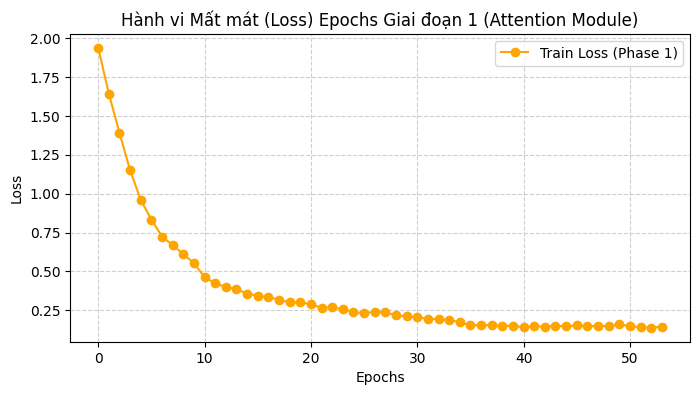

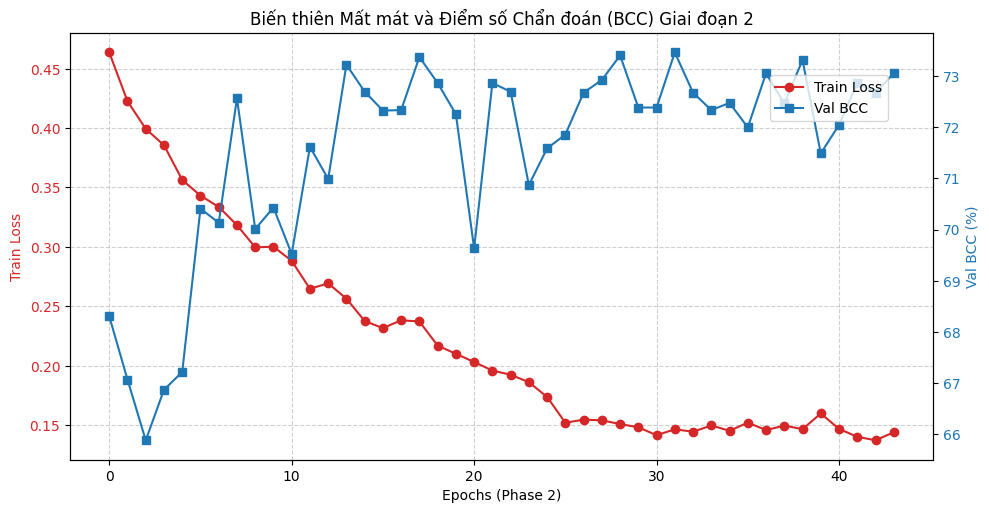

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted verbatim from your previous training outputs
train_loss_p1 = [1.9397, 1.6437, 1.3922, 1.1502, 0.9603, 0.8331, 0.7242, 0.6687, 0.6113, 0.5521, 0.4636, 0.4225, 0.3993, 0.3855, 0.3563, 0.3431, 0.3336, 0.3183, 0.2996, 0.3001, 0.2882, 0.2647, 0.2693, 0.2564, 0.2376, 0.2316, 0.2382, 0.2372, 0.2169, 0.21, 0.2031, 0.1959, 0.1924, 0.1861, 0.1737, 0.152, 0.1546, 0.154, 0.1509, 0.1482, 0.1415, 0.1465, 0.1444, 0.1497, 0.1452, 0.1521, 0.1458, 0.1496, 0.1466, 0.1598, 0.1468, 0.1402, 0.1372, 0.144]
train_loss_p2 = [0.4636, 0.4225, 0.3993, 0.3855, 0.3563, 0.3431, 0.3336, 0.3183, 0.2996, 0.3001, 0.2882, 0.2647, 0.2693, 0.2564, 0.2376, 0.2316, 0.2382, 0.2372, 0.2169, 0.21, 0.2031, 0.1959, 0.1924, 0.1861, 0.1737, 0.152, 0.1546, 0.154, 0.1509, 0.1482, 0.1415, 0.1465, 0.1444, 0.1497, 0.1452, 0.1521, 0.1458, 0.1496, 0.1466, 0.1598, 0.1468, 0.1402, 0.1372, 0.144]
val_bcc_p2 = [68.3, 67.06, 65.87, 66.86, 67.21, 70.41, 70.13, 72.57, 70.01, 70.43, 69.52, 71.62, 70.99, 73.23, 72.7, 72.33, 72.34, 73.38, 72.87, 72.26, 69.63, 72.87, 72.7, 70.87, 71.59, 71.86, 72.68, 72.93, 73.41, 72.39, 72.39, 73.47, 72.68, 72.34, 72.48, 72.0, 73.06, 72.47, 73.32, 71.49, 72.05, 72.87, 72.68, 73.06]

# Plot Phase 1 Loss (if exists)
if len(train_loss_p1) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss_p1, label='Train Loss (Phase 1)', color='orange', marker='o')
    plt.title('Hành vi Mất mát (Loss) Epochs Giai đoạn 1 (Attention Module)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Plot Phase 2 Loss and BCC
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epochs (Phase 2)')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(train_loss_p2, color=color, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Val BCC (%)', color=color)  
ax2.plot(val_bcc_p2, color=color, marker='s', label='Val BCC')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Biến thiên Mất mát và Điểm số Chẩn đoán (BCC) Giai đoạn 2')
ax1.grid(True, linestyle='--', alpha=0.6)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

In [8]:
# --- BÁO CÁO CHI TIẾT TỪNG NHÃN (CLASS-WISE) ---
model.load_state_dict(torch.load(best_model_path))
model.eval()
final_preds, final_trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in test_loader:
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        final_preds.extend(y_hat.cpu().numpy())
        final_trues.extend(lbls.numpy())

from sklearn.metrics import classification_report
print("=== BÁO CÁO F1, RECALL THEO TỪNG NHÃN QUAN TRỌNG (BEST MODEL) ===")
print(classification_report(final_trues, final_preds, digits=4))


=== BÁO CÁO F1, RECALL THEO TỪNG NHÃN QUAN TRỌNG (BEST MODEL) ===
              precision    recall  f1-score   support

           0     0.8264    0.7874    0.8065       127
           1     0.7500    0.6379    0.6894       174
           2     0.5455    0.8571    0.6667         7
           3     0.8409    0.7551    0.7957        49
           4     0.2500    0.4082    0.3101        49
           5     0.8070    0.8364    0.8214        55

    accuracy                         0.6941       461
   macro avg     0.6700    0.7137    0.6816       461
weighted avg     0.7313    0.6941    0.7080       461

